In [8]:
import os
import sys
import numpy as np

# Compute project root (one level up from notebook directory)
notebook_dir = os.path.abspath("")
project_root = os.path.abspath(os.path.join(notebook_dir, ".."))
build_dir = os.path.join(project_root, "build")

# Insert build/ and project root into Python search path
if build_dir not in sys.path:
    sys.path.insert(0, build_dir)
if project_root not in sys.path:
    sys.path.insert(0, project_root)

# Import C++ module and strategy classes
import _low_latency_cpp as hft
from strategy.alpha_engine import MicrostructureAlphaEngine
from strategy.backtest_driver import HybridBacktestDriver

# Synthetic stream generator function
def generate_synthetic_stream(num_events: int = 5000) -> list:
    events = []
    base_price = 500
    np.random.seed(42)

    for i in range(num_events):
        event = hft.MarketEvent()
        event.order_id = i + 1
        event.timestamp_ns = (i + 1) * 1000

        if (i // 500) % 2 == 0:
            if i % 2 == 0:
                event.side = hft.Side.BID
                event.price = base_price
                event.qty = int(np.random.randint(500, 1500))
            else:
                event.side = hft.Side.ASK
                event.price = base_price + 2
                event.qty = int(np.random.randint(50, 150))
        else:
            if i % 2 == 0:
                event.side = hft.Side.BID
                event.price = base_price
                event.qty = int(np.random.randint(50, 150))
            else:
                event.side = hft.Side.ASK
                event.price = base_price + 2
                event.qty = int(np.random.randint(500, 1500))

        events.append(event)
    return events

print("Project Root:", project_root)
print("Build Directory:", build_dir)
print("Successfully loaded C++ module and strategy classes!")

Project Root: /Users/rahulkrishna/Desktop/Coding/CP/projects/low-latency-backtesting-framework
Build Directory: /Users/rahulkrishna/Desktop/Coding/CP/projects/low-latency-backtesting-framework/build
Successfully loaded C++ module and strategy classes!


In [9]:
# Initialize order book
book = hft.FlatOrderBook()

# Get zero-copy NumPy buffer views directly over raw C++ memory pointers
bids = book.get_bids_zerocopy()
asks = book.get_asks_zerocopy()

print("C++ Bids Pointer Address :", hex(bids.__array_interface__['data'][0]))
print("Initial Volume @ Level 500 :", bids[500])

# Add orders directly in C++
order_1 = book.add_order(101, 500, 1500, hft.Side.BID)
order_2 = book.add_order(102, 502, 600, hft.Side.ASK)

# Value updates in Python instantly without language interop overhead
print("Updated Volume @ Level 500 :", bids[500])
print("Updated Volume @ Level 502 :", asks[502])

C++ Bids Pointer Address : 0x7ff041e7c2c4
Initial Volume @ Level 500 : 0
Updated Volume @ Level 500 : 1500
Updated Volume @ Level 502 : 600


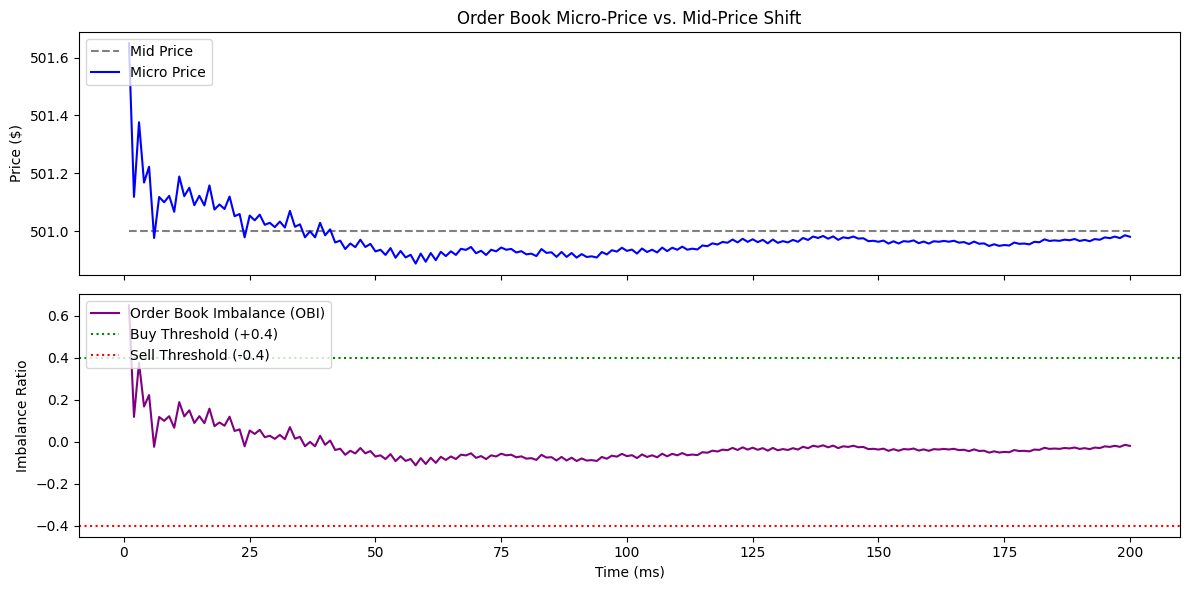

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

alpha_engine = MicrostructureAlphaEngine(book, obi_threshold=0.4)
signals_data = []

# Simulate ticks
for i in range(200):
    event = hft.MarketEvent()
    event.order_id = 1000 + i
    event.price = 500 if i % 2 == 0 else 502
    event.qty = int(np.random.randint(200, 2500))
    event.side = hft.Side.BID if i % 2 == 0 else hft.Side.ASK
    event.timestamp_ns = (i + 1) * 1_000_000
    
    book.apply_event(event)
    sig = alpha_engine.calculate_signals(timestamp_ns=event.timestamp_ns)
    
    signals_data.append({
        "time_ms": event.timestamp_ns / 1e6,
        "mid_price": sig.mid_price,
        "micro_price": sig.micro_price,
        "obi": sig.obi,
        "signal": sig.signal
    })

df = pd.DataFrame(signals_data)

# Visual Plotting
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

ax1.plot(df["time_ms"], df["mid_price"], label="Mid Price", color="gray", linestyle="--")
ax1.plot(df["time_ms"], df["micro_price"], label="Micro Price", color="blue", linewidth=1.5)
ax1.set_ylabel("Price ($)")
ax1.set_title("Order Book Micro-Price vs. Mid-Price Shift")
ax1.legend(loc="upper left")

ax2.plot(df["time_ms"], df["obi"], label="Order Book Imbalance (OBI)", color="purple")
ax2.axhline(0.4, color="green", linestyle=":", label="Buy Threshold (+0.4)")
ax2.axhline(-0.4, color="red", linestyle=":", label="Sell Threshold (-0.4)")
ax2.set_ylabel("Imbalance Ratio")
ax2.set_xlabel("Time (ms)")
ax2.legend(loc="upper left")

plt.tight_layout()
plt.show()

In [11]:
import time

events = generate_synthetic_stream(num_events=50_000)

driver = HybridBacktestDriver(
    obi_threshold=0.5,
    order_qty=10,
    transaction_fee_bps=0.1,
    latency_penalty_events=2
)

latencies_us = []
start_wall = time.perf_counter()

for event in events:
    t0 = time.perf_counter_ns()
    driver.process_event(event)
    latencies_us.append((time.perf_counter_ns() - t0) / 1000.0)

elapsed_sec = time.perf_counter() - start_wall

print(f"================ BACKTEST PERFORMANCE ================")
print(f"Total Processed Events : {len(events):,}")
print(f"Total Wall Clock Time  : {elapsed_sec:.3f} seconds")
print(f"Throughput             : {len(events)/elapsed_sec:,.0f} events/sec")
print(f"Total Trades Executed  : {len(driver.trades)}")
print(f"Final Realized PnL    : ${driver.realized_pnl:.2f}")
print("------------------------------------------------------")
print(f"Mean Latency           : {np.mean(latencies_us):.2f} µs")
print(f"P50 Latency            : {np.percentile(latencies_us, 50):.2f} µs")
print(f"P99 Latency            : {np.percentile(latencies_us, 99):.2f} µs")
print("======================================================")

================ BACKTEST PERFORMANCE ================
Total Processed Events : 50,000
Total Wall Clock Time  : 4.202 seconds
Throughput             : 11,899 events/sec
Total Trades Executed  : 616
Final Realized PnL    : $0.00
------------------------------------------------------
Mean Latency           : 83.60 µs
P50 Latency            : 76.99 µs
P99 Latency            : 202.35 µs


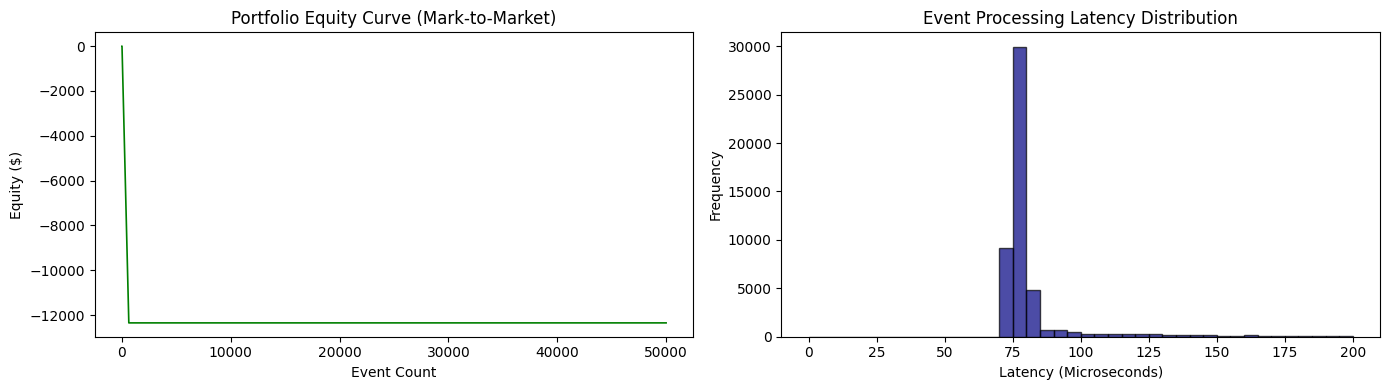

In [13]:
fig, (ax_eq, ax_lat) = plt.subplots(1, 2, figsize=(14, 4))

# Equity Curve Plot
ax_eq.plot(driver.equity_curve, color="green", linewidth=1.2)
ax_eq.set_title("Portfolio Equity Curve (Mark-to-Market)")
ax_eq.set_xlabel("Event Count")
ax_eq.set_ylabel("Equity ($)")

# Latency Histogram Plot
ax_lat.hist(latencies_us, bins=40, range=(0, 200), color="navy", alpha=0.7, edgecolor="black")
ax_lat.set_title("Event Processing Latency Distribution")
ax_lat.set_xlabel("Latency (Microseconds)")
ax_lat.set_ylabel("Frequency")

plt.tight_layout()
plt.show()